# The Shrinking Club: Who's Been Pushed Out of Frontier AI Development?

**An empirical analysis of institutional, organizational, and geographic concentration in AI model development (2015–2026)**

*Data source: [Epoch AI — Notable AI Models](https://epoch.ai/data/ai-models) (updated May 2026, Creative Commons Attribution 4.0)*

---

A decade ago, universities, government labs, and mid-size companies all contributed to the frontier of AI research. That's no longer true. Using Epoch AI's database of over 1,000 notable machine learning models, this analysis tracks who has been systematically pushed out of frontier AI development — and what that concentration means for governance, competition, and the future of the field.

The findings are stark. Academia's share of notable AI model production has fallen from roughly 45% to effectively zero. Dozens of institutions that helped build the field — MIT, Oxford, Cambridge, the Chinese Academy of Sciences — no longer produce models that meet Epoch's notability criteria. The compute costs that explain this exclusion have grown by orders of magnitude, creating a barrier that no university budget can cross. And the geographic picture is equally lopsided: 85 of 123 frontier models — 69% — come from a single country.

In [1]:
# Pull the latest data directly from Epoch AI
!wget -q https://epoch.ai/data/notable_ai_models.csv

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#cccccc',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

palette = {
    'industry': '#1a1a2e',
    'academia': '#e07a5f',
    'mixed': '#81b29a',
    'govt': '#f2cc8f',
    'accent': '#e63946',
    'muted': '#adb5bd',
}

geo_colors = {
    'us': '#264653',
    'uk': '#2a9d8f',
    'canada': '#e9c46a',
    'china': '#e76f51',
    'other': '#adb5bd',
}

## Loading and preparing the data

The dataset tracks notable AI models from 1950 to April 2026. Each record includes the model name, the developing organization, country, training compute, and whether the model's weights were released publicly. Epoch defines "notable" as models that achieved state-of-the-art results on a recognized benchmark, received over 1,000 citations, or had significant real-world use.

All 2026 figures in this analysis reflect data through April 24, 2026 only. The dataset is updated continuously, so full-year numbers will differ.

In [12]:
df = pd.read_csv('notable_ai_models.csv')

df['pub_date'] = pd.to_datetime(df['Publication date'])
df['year'] = df['pub_date'].dt.year
df['primary_org'] = df['Organization'].str.split(',').str[0].str.strip()
df['primary_org_type'] = df['Organization categorization'].str.split(',').str[0].str.strip()
df['primary_country'] = df['Country (of organization)'].str.split(',').str[0].str.strip()

# shorten some of the longer country names for readability
country_renames = {
    'United States of America': 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Korea (Republic of)': 'South Korea',
    'United Arab Emirates': 'UAE',
}
df['country_clean'] = df['primary_country'].map(country_renames).fillna(df['primary_country'])

print(f"Dataset: {len(df)} notable AI models, {int(df['year'].min())}–{int(df['year'].max())}")
print(f"Unique organizations: {df['primary_org'].nunique()}")
print(f"Unique countries: {df['country_clean'].nunique()}")

Dataset: 1017 notable AI models, 1950–2026
Unique organizations: 236
Unique countries: 27


## 1. The academic collapse

The single most striking trend in this dataset is the disappearance of academia from notable AI model production. In 2015, universities produced roughly 45% of all notable models — a reflection of AI's roots as an academic discipline. By 2025, that share had dropped to 2%. In the first four months of 2026, not a single notable model came from a university. (The 2026 figure covers January through April only; the full-year picture may differ.)

This isn't a story about universities doing less research. They're publishing more papers than ever. It's that the kind of AI work that registers as "notable" — hitting state-of-the-art benchmarks, attracting thousands of citations, seeing widespread deployment — now requires resources that only industry can provide.

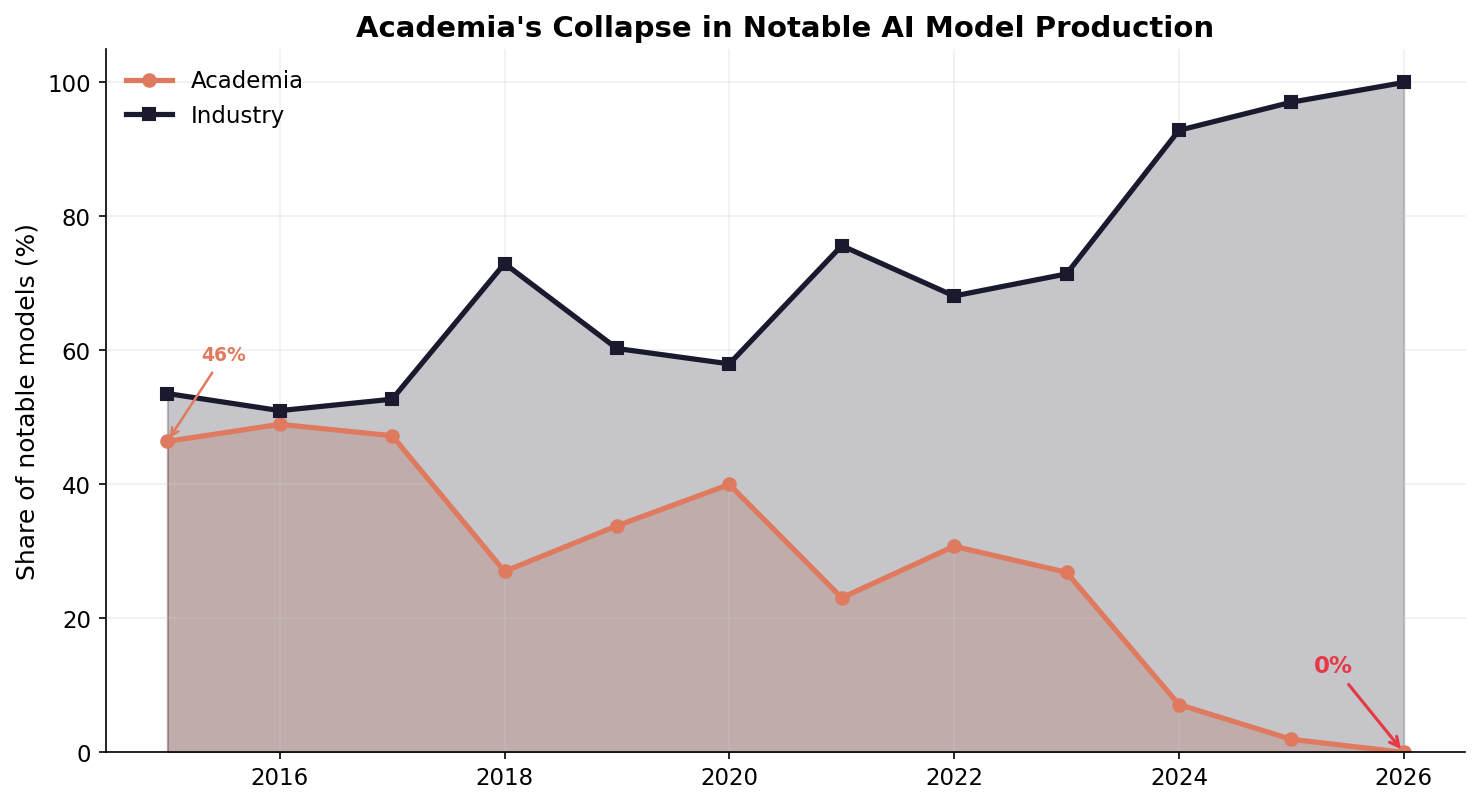

In [4]:
yearly = df[df['year'] >= 2015].groupby('year')['primary_org_type'].value_counts().unstack(fill_value=0)
for col in ['Academia', 'Industry']:
    if col not in yearly.columns:
        yearly[col] = 0

yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100
aca_2015 = yearly_pct.loc[2015, 'Academia']

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.fill_between(yearly_pct.index, yearly_pct['Academia'], alpha=0.25, color=palette['academia'])
ax.fill_between(yearly_pct.index, yearly_pct['Industry'], alpha=0.25, color=palette['industry'])
ax.plot(yearly_pct.index, yearly_pct['Academia'], color=palette['academia'],
        linewidth=2.5, marker='o', markersize=6, label='Academia')
ax.plot(yearly_pct.index, yearly_pct['Industry'], color=palette['industry'],
        linewidth=2.5, marker='s', markersize=6, label='Industry')

ax.set_title("Academia's Collapse in Notable AI Model Production")
ax.set_ylabel('Share of notable models (%)')
ax.set_ylim(0, 105)
ax.legend(frameon=False, fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# annotate the start and end points
ax.annotate(f'{aca_2015:.0f}%', xy=(2015, aca_2015), xytext=(2015.3, aca_2015 + 12),
            fontsize=9, color=palette['academia'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=palette['academia'], lw=1.2))
ax.annotate('0%', xy=(2026, 0), xytext=(2025.2, 12),
            fontsize=11, color=palette['accent'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=palette['accent'], lw=1.5))

plt.tight_layout()
plt.show()

The crossover happened around 2018, which lines up with the release of BERT and GPT-2 — models that signaled a shift toward scale as the primary driver of performance. Once "bigger is better" became the dominant paradigm, universities couldn't keep up. The trend accelerated sharply after 2023.

## 2. Who dropped out — and who they were

To put names to this trend, I compared which organizations were producing notable models in 2015–2019 against which ones are still active in 2023–2026. The attrition list reads like a roster of institutions that shaped the field.

A methodological note: some apparent dropouts are actually rebrandings. Google Brain merged into Google DeepMind in 2023. Facebook AI became Meta AI. These aren't exits — they're reorganizations within the same companies. I've excluded these from the chart below to focus on genuine departures.

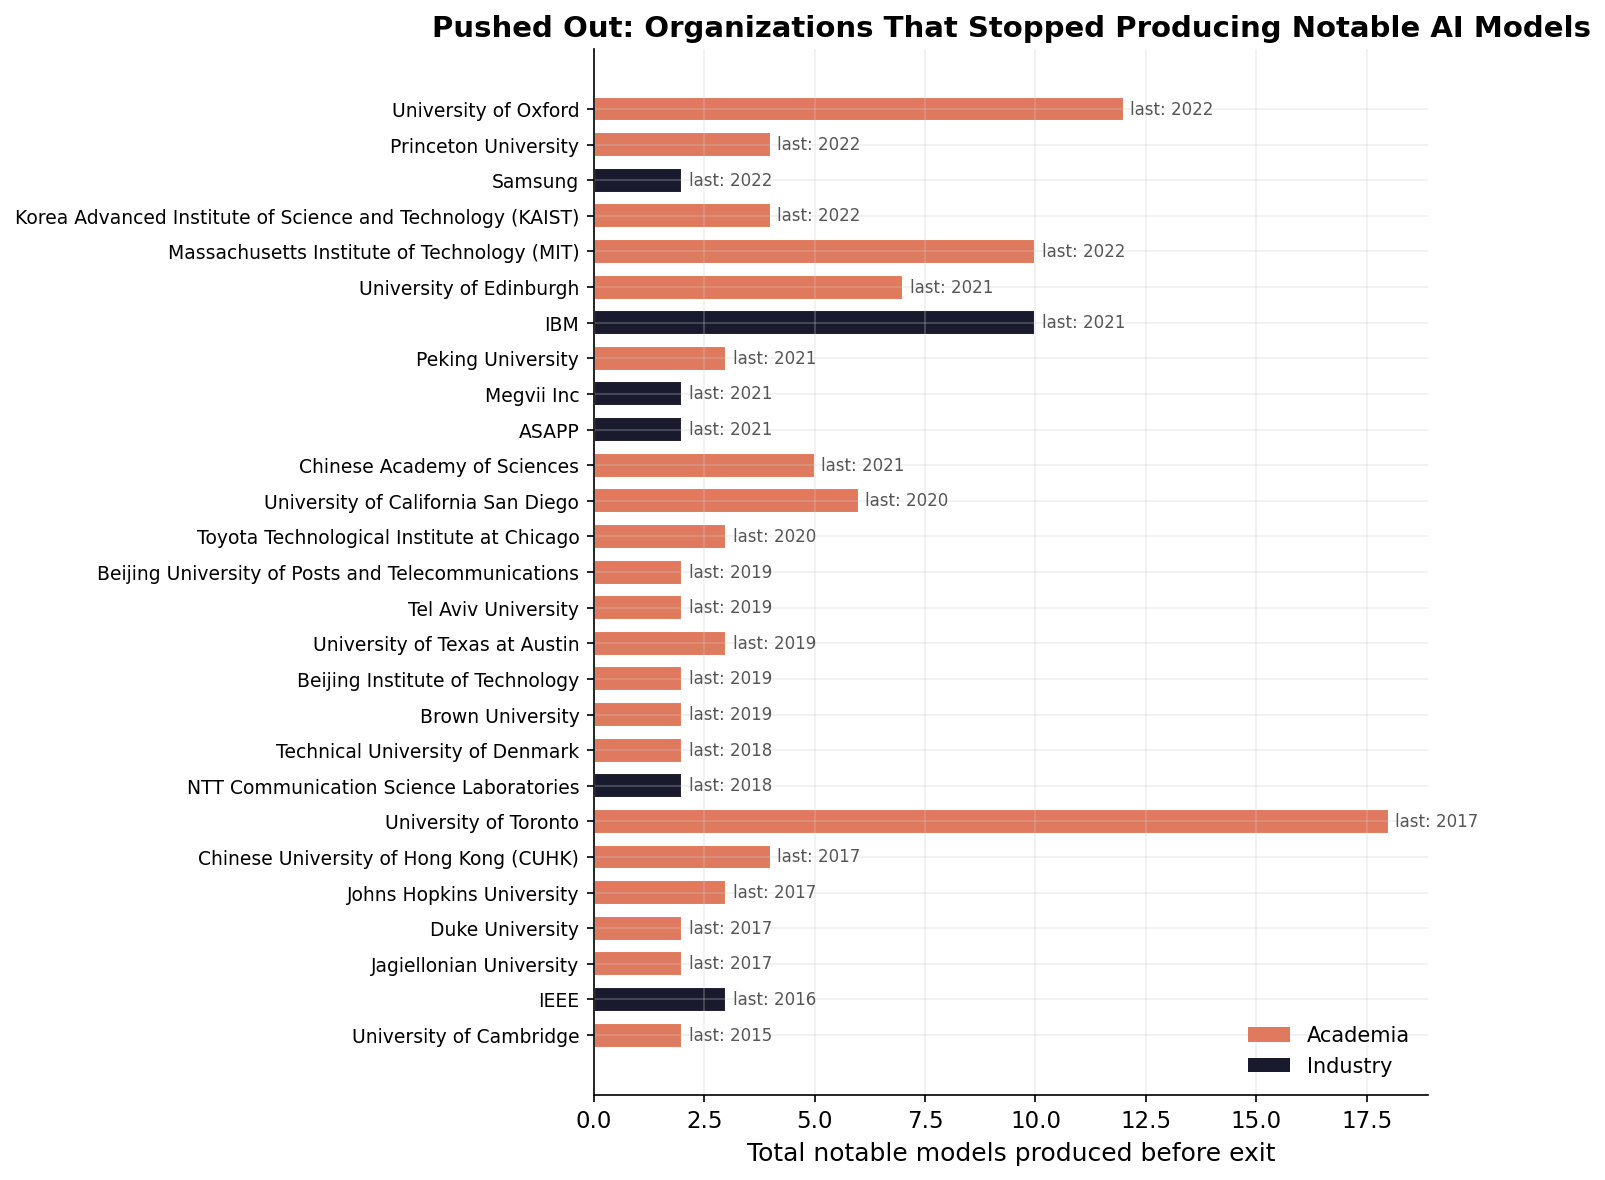


Genuine exits (2+ models): 27 organizations
Of those, 21 were academic institutions.


In [5]:
early = df[(df['year'] >= 2015) & (df['year'] <= 2019)]
recent = df[(df['year'] >= 2023)]

early_orgs = set(early['primary_org'].dropna().unique())
recent_orgs = set(recent['primary_org'].dropna().unique())

# these orgs were renamed/merged, not pushed out
rebrands = {'Google Brain', 'Facebook AI', 'Microsoft Research', 'Microsoft Research Asia', 'DeepMind'}

dropped_details = []
for org in sorted(early_orgs - recent_orgs):
    org_data = df[df['primary_org'] == org]
    org_type = org_data['primary_org_type'].mode().iloc[0] if len(org_data) > 0 else 'Unknown'
    last_year = int(org_data['year'].max())
    n_models = len(org_data)

    if org in rebrands:
        continue
    if org_type not in ['Academia', 'Industry', 'Government', 'Research collective']:
        continue

    dropped_details.append({
        'org': org, 'type': org_type,
        'last_year': last_year, 'n_models': n_models
    })

dropped_df = pd.DataFrame(dropped_details)

# only show orgs that produced at least 2 models — single-model orgs
# could just be one-off collaborations
notable_dropped = dropped_df[dropped_df['n_models'] >= 2].sort_values('last_year')

type_colors = {
    'Academia': palette['academia'],
    'Industry': palette['industry'],
    'Government': palette['govt'],
    'Research collective': palette['mixed'],
}

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(notable_dropped))
bar_colors = [type_colors.get(t, palette['muted']) for t in notable_dropped['type']]

ax.barh(y_pos, notable_dropped['n_models'], color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(notable_dropped['org'], fontsize=9)
ax.set_xlabel('Total notable models produced before exit')
ax.set_title('Pushed Out: Organizations That Stopped Producing Notable AI Models')

for i, (_, row) in enumerate(notable_dropped.iterrows()):
    ax.text(row['n_models'] + 0.15, i, f"last: {row['last_year']}",
            va='center', fontsize=8, color='#555555')

legend_items = [Patch(facecolor=palette['academia'], label='Academia'),
                Patch(facecolor=palette['industry'], label='Industry')]
ax.legend(handles=legend_items, frameon=False, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

n_aca = (notable_dropped['type'] == 'Academia').sum()
print(f"\nGenuine exits (2+ models): {len(notable_dropped)} organizations")
print(f"Of those, {n_aca} were academic institutions.")

The pattern is clear: the vast majority of exits are universities. Oxford, MIT, KAIST, UC San Diego, Cambridge, the Chinese Academy of Sciences, Toronto — all institutions with deep histories in machine learning research.

What's left is a small club of mostly American tech companies, plus a handful of well-funded Chinese labs and a few European startups.

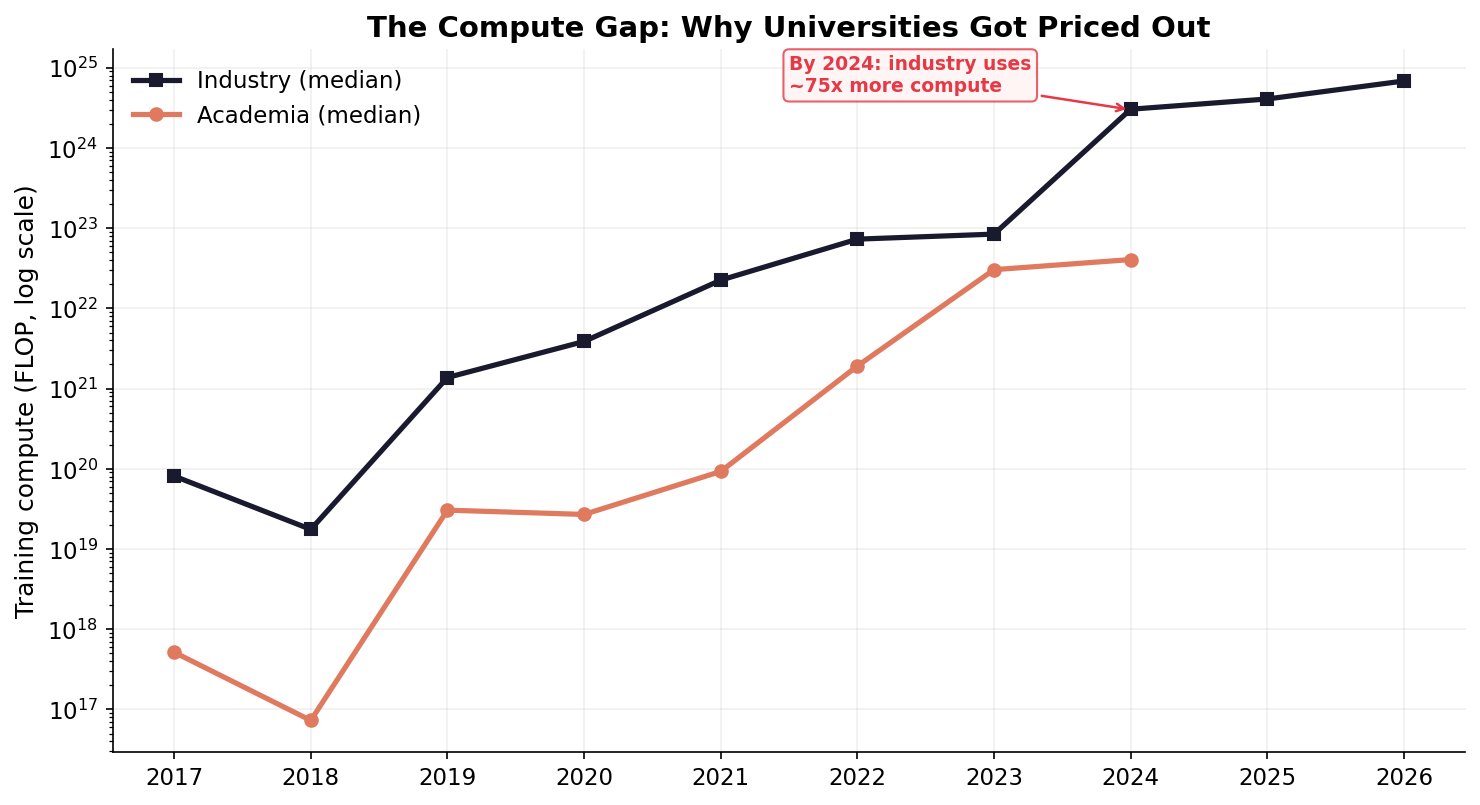

2019: industry/academia compute ratio = 45x
2021: industry/academia compute ratio = 243x
2023: industry/academia compute ratio = 3x
2024: industry/academia compute ratio = 75x


In [19]:
df_compute = df[(df['Training compute (FLOP)'].notna()) & (df['year'] >= 2017)].copy()
median_compute = df_compute.groupby(['year', 'primary_org_type'])['Training compute (FLOP)'].median().unstack()

fig, ax = plt.subplots(figsize=(10, 5.5))

if 'Industry' in median_compute.columns:
    ax.plot(median_compute.index, median_compute['Industry'], color=palette['industry'],
            linewidth=2.5, marker='s', markersize=6, label='Industry (median)')
if 'Academia' in median_compute.columns:
    ax.plot(median_compute.index, median_compute['Academia'], color=palette['academia'],
            linewidth=2.5, marker='o', markersize=6, label='Academia (median)')

ax.set_yscale('log')
ax.set_title('The Compute Gap: Why Universities Got Priced Out')
ax.set_ylabel('Training compute (FLOP, log scale)')
ax.legend(frameon=False, fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# the 2024 gap is roughly 75x — worth flagging
ax.annotate('By 2024: industry uses\n~75x more compute', xy=(2024, 3e24),
            xytext=(2021.5, 5e24), fontsize=9, fontweight='bold', color=palette['accent'],
            arrowprops=dict(arrowstyle='->', color=palette['accent'], lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3f3',
                      edgecolor=palette['accent'], alpha=0.8))

plt.tight_layout()
plt.show()

# print the actual ratios where both exist
for yr in [2019, 2021, 2023, 2024]:
    if yr in median_compute.index:
        ind = median_compute.loc[yr].get('Industry', None)
        aca = median_compute.loc[yr].get('Academia', None)
        if ind and aca and aca > 0:
            print(f"{yr}: industry/academia compute ratio = {ind/aca:.0f}x")

## 3. The compute gap — the mechanism of exclusion

The reason universities can't compete is straightforward: training compute. The median industry model now uses orders of magnitude more compute than the median academic model. This isn't a gap that better algorithms or smarter researchers can close — it's a resource barrier, and it's growing.

Notice that the academic line simply ends after 2024. It doesn't converge with industry or plateau at a lower level — it disappears. There are too few academic models in 2025 and 2026 to even compute a meaningful median. The game isn't that academia is losing; it's that academia is no longer on the field.

This has implications beyond AI research. Universities have historically served as a counterweight to industry — producing independent evaluations, training the next generation of researchers, and pursuing work that isn't driven by commercial incentives. When universities can't participate in frontier development, that oversight function erodes.

## 4. Geographic concentration — a one-country frontier

The dataset also tracks where each model's developing organization is based. For frontier models specifically — those that were in the top 10 of training compute at the time of release — the geographic picture is dominated by a single country.

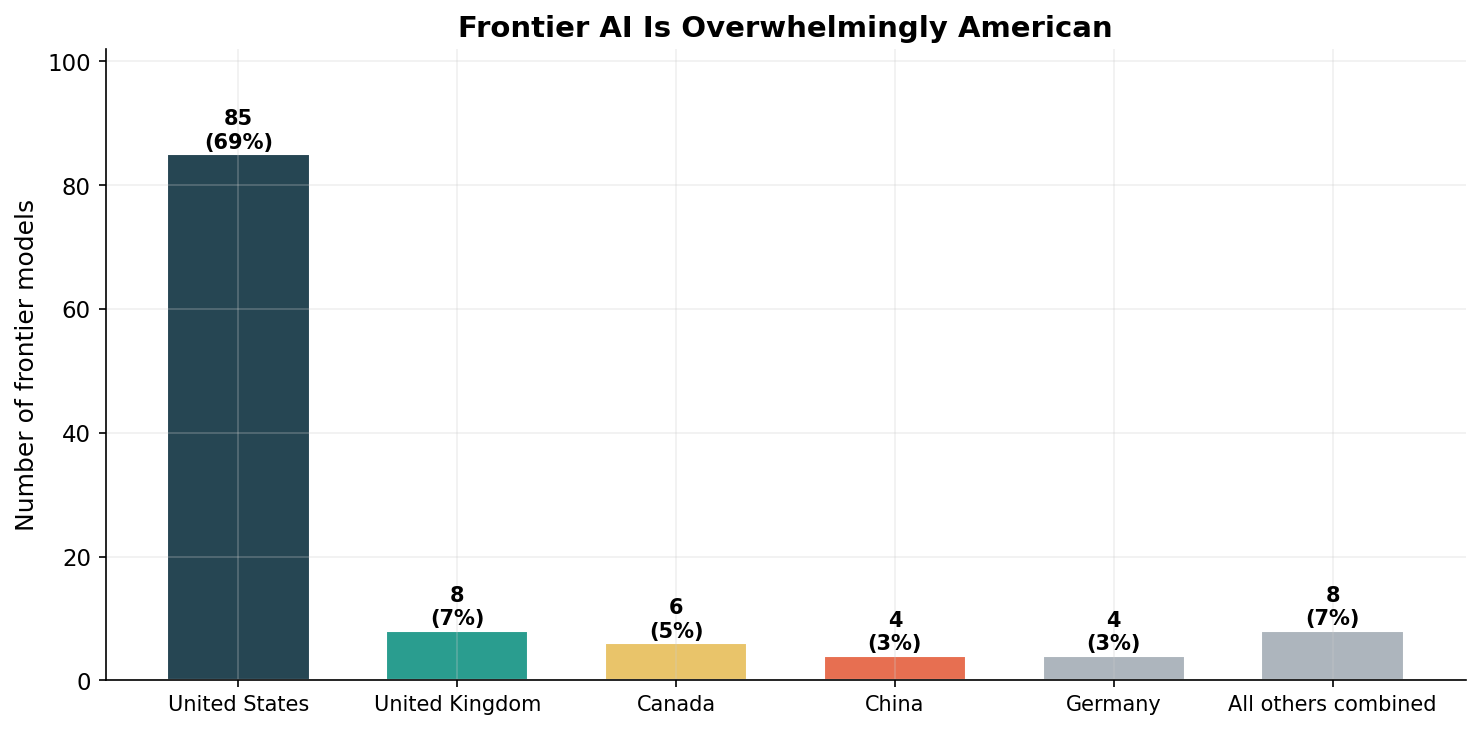


US share of frontier: 85/123 = 69%


In [7]:
frontier = df[df['Frontier model'] == True].copy()
frontier['country_clean'] = frontier['primary_country'].map(country_renames).fillna(frontier['primary_country'])
total_frontier = len(frontier)

country_counts = frontier['country_clean'].value_counts()
top5 = country_counts.head(5)
others = country_counts.iloc[5:].sum()
plot_data = pd.concat([top5, pd.Series({'All others combined': others})])

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [geo_colors['us'], geo_colors['uk'], geo_colors['canada'],
              geo_colors['china'], geo_colors['other'], palette['muted']]

ax.bar(range(len(plot_data)), plot_data.values,
       color=bar_colors[:len(plot_data)], edgecolor='white', width=0.65)
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data.index, fontsize=10)
ax.set_ylabel('Number of frontier models')
ax.set_title('Frontier AI Is Overwhelmingly American')

# percentages of total frontier, not just those with country data
for i, val in enumerate(plot_data.values):
    pct = val / total_frontier * 100
    ax.text(i, val + 1, f'{val}\n({pct:.0f}%)', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, plot_data.max() * 1.2)
plt.tight_layout()
plt.show()

us_count = top5.iloc[0]
print(f"\nUS share of frontier: {us_count}/{total_frontier} = {us_count/total_frontier*100:.0f}%")

69% of all frontier models (85 of 123) originate from U.S.-based organizations. China — despite producing the second-most notable models overall — has only 4 frontier models, or 3% of the total. The UK, Canada, and Germany each have single-digit counts.

This concentration matters for AI governance because it means that the rules, norms, and safety practices that shape frontier AI development are overwhelmingly determined by the regulatory environment and corporate culture of one country. International AI governance frameworks are being negotiated as though multiple nations have a stake in frontier development, but the data suggests the frontier is essentially an American phenomenon — with a small and recent Chinese challenge.

## 5. The shrinking competition at the top

Rather than using Epoch's formal "frontier" label, we can ask how many distinct organizations are operating in the top quartile of training compute each year. This gives a broader picture of competitive intensity at the high end.

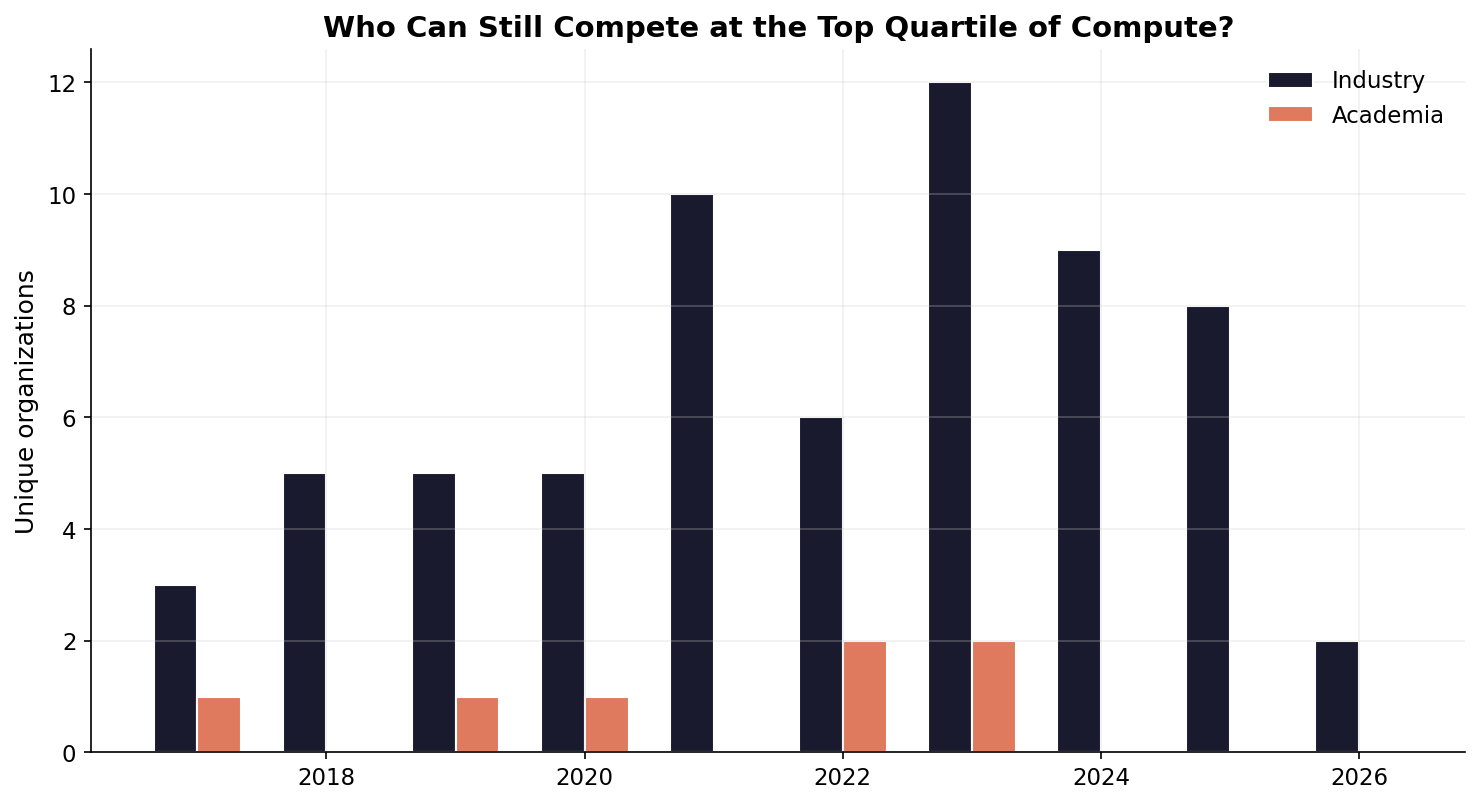

In [8]:
df_with_compute = df[df['Training compute (FLOP)'].notna()].copy()

yearly_stats = []
for year in range(2017, 2027):
    yr_data = df_with_compute[df_with_compute['year'] == year]
    if len(yr_data) == 0:
        continue

    q75 = yr_data['Training compute (FLOP)'].quantile(0.75)
    top_tier = yr_data[yr_data['Training compute (FLOP)'] >= q75]

    n_aca = top_tier[top_tier['primary_org_type'] == 'Academia']['primary_org'].nunique()
    n_ind = top_tier[top_tier['primary_org_type'] == 'Industry']['primary_org'].nunique()
    yearly_stats.append({'year': year, 'academia': n_aca, 'industry': n_ind})

stats_df = pd.DataFrame(yearly_stats)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(stats_df['year'] - 0.17, stats_df['industry'], width=0.34,
       color=palette['industry'], label='Industry', edgecolor='white')
ax.bar(stats_df['year'] + 0.17, stats_df['academia'], width=0.34,
       color=palette['academia'], label='Academia', edgecolor='white')

ax.set_title('Who Can Still Compete at the Top Quartile of Compute?')
ax.set_ylabel('Unique organizations')
ax.legend(frameon=False, fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

Academic presence in the top quartile has never been large, but it's now essentially gone. The number of industry organizations competing at the top grew from about 3 in 2017 to 12 in 2023, then started declining as compute costs pushed even some companies out. By 2026 (through April), the data shows only 2 organizations operating in the top quartile — a level of concentration that would raise antitrust flags in any other industry.

## 6. Model accessibility — does openness compensate?

One counterargument is that even if fewer organizations are *building* frontier models, openness — releasing model weights, publishing code — could democratize access. If frontier labs release their models for others to use and build on, maybe the concentration of *production* matters less. Here's what the data says about accessibility trends over time.

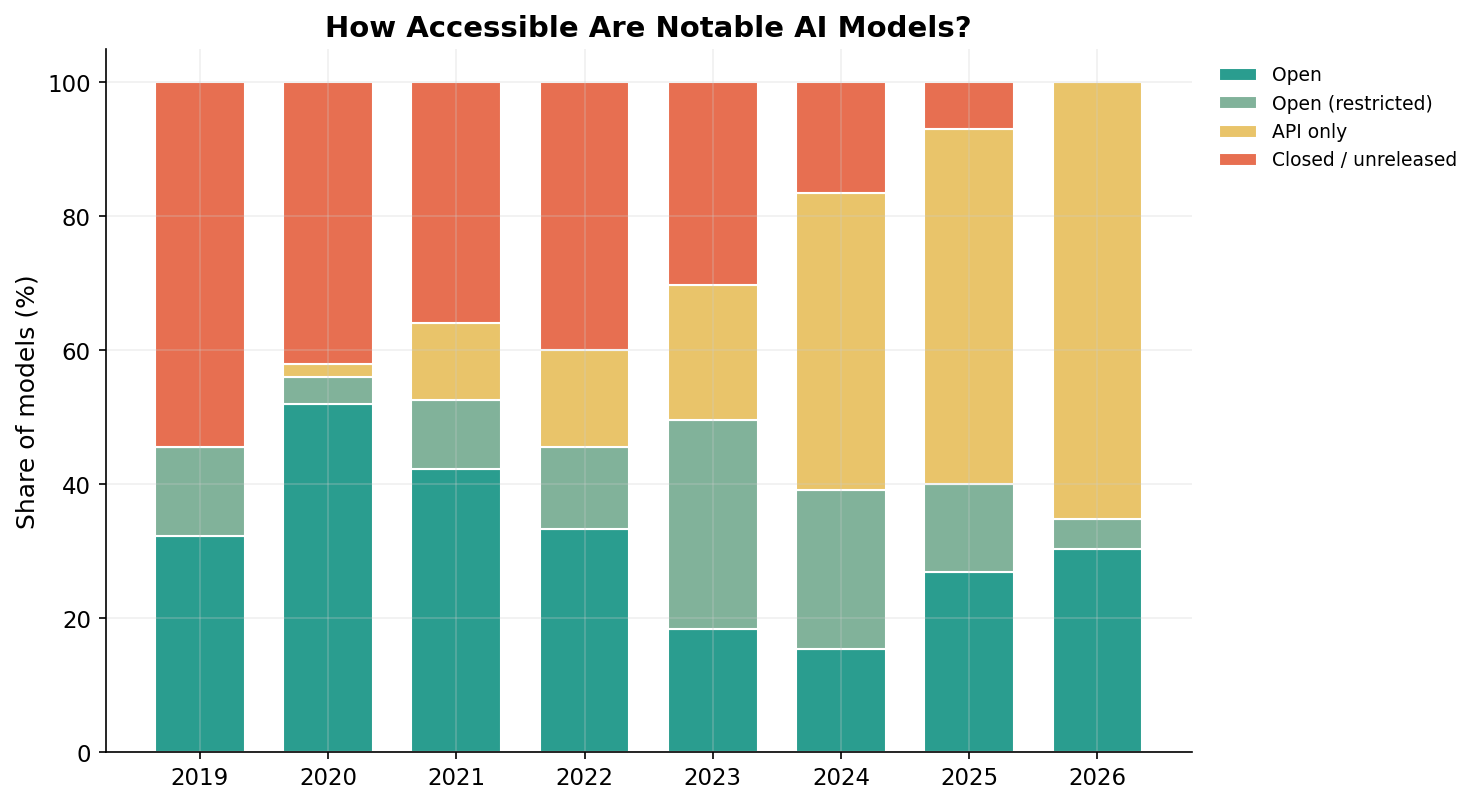

In [9]:
access = df[df['year'] >= 2019].copy()
access['access_bucket'] = access['Model accessibility'].map({
    'Open weights (unrestricted)': 'Open',
    'Open weights (non-commercial)': 'Open (restricted)',
    'Open weights (restricted use)': 'Open (restricted)',
    'API access': 'API only',
    'Hosted access (no API)': 'API only',
    'Unreleased': 'Closed / unreleased'
})

access_ct = pd.crosstab(access['year'], access['access_bucket'])
access_pct = access_ct.div(access_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

categories = ['Open', 'Open (restricted)', 'API only', 'Closed / unreleased']
cat_colors = ['#2a9d8f', '#81b29a', '#e9c46a', '#e76f51']

bottom = np.zeros(len(access_pct))
for cat, color in zip(categories, cat_colors):
    if cat in access_pct.columns:
        vals = access_pct[cat].values
        ax.bar(access_pct.index, vals, bottom=bottom, color=color,
               label=cat, width=0.7, edgecolor='white')
        bottom += vals

ax.set_title('How Accessible Are Notable AI Models?')
ax.set_ylabel('Share of models (%)')
ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

The picture is mixed. Fully open models (unrestricted weights) peaked around 2020 and have since declined as a share of notable models. Meanwhile, API-only access has grown substantially — you can *use* the model, but you can't inspect it, modify it, or build on it independently.

In other words, the dominant trend is toward *access as a service* rather than access as a shared resource. Users get to query frontier models; they don't get to understand or reproduce them. That's a meaningful distinction for researchers, for auditors, and for anyone concerned about the concentration of power in a small number of providers.

## What this means

The data tells a consistent story across every dimension: the club of organizations capable of producing frontier AI is shrinking, not growing. Universities have been almost entirely excluded. Most countries play no role at the frontier. Even within industry, the number of competitive players at the top is declining.

Regulatory frameworks that assume a diverse ecosystem of AI developers — where competition and academic oversight provide natural checks — are building on a foundation that no longer exists. Safety evaluations that depend on access to model internals face an industry moving toward API-only access. International governance negotiations involve dozens of countries, but the frontier is being built in essentially one.

None of this is necessarily permanent. Algorithmic efficiency gains could lower the compute barrier. Government compute programs (like the U.S. National AI Research Resource) could give universities back a seat at the table. Open-source efforts could provide alternative pathways to frontier capability. But right now, the direction of travel is toward more concentration, not less — and the pace is accelerating.

---

**Methodology note:** This analysis uses Epoch AI's Notable AI Models dataset (updated May 2026), containing 1,017 models spanning 1950 to April 2026. All 2026 figures reflect data through April 24, 2026 only. Organization type is assigned by Epoch AI; for multi-affiliation models I use the first listed organization. "Frontier" models are those Epoch classifies as being in the top 10 of training compute at the time of their release.

*Data: [Epoch AI](https://epoch.ai/data/ai-models), "Data on AI Models." CC-BY 4.0.*